# Actividad 4: Análisis de Datos Biomédicos
## Cambio de base sobre datos biomédicos

En esta actividad repetiremos el análisis de **cambio de base** aplicado a un conjunto de datos biomédicos con tres variables:

- **Biome_size**: tamaño corporal del paciente (cm).
- **Thyroid_size**: tamaño de la glándula tiroides (g).
- **Red_blood_cell_levels**: nivel de glóbulos rojos en sangre (millones/\u00b5L).

El objetivo es transformar estos datos a una nueva base $B'$, comparar la distribución de las coordenadas resultantes con las originales mediante histogramas y visualizar el resultado en un espacio tridimensional.

La nueva base propuesta es:

$$B' = \begin{pmatrix} 0.7 & 0.7 & 0 \\ 0.5 & -0.5 & 0.7 \\ -0.5 & 0.5 & 0.7 \end{pmatrix}$$

Este ejercicio es análogo al realizado previamente sobre otro conjunto de datos, donde se observó un efecto de **reducción de varianza** en una de las nuevas coordenadas.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

np.random.seed(42)
plt.rcParams['figure.figsize'] = (8, 5)
plt.rcParams['axes.grid'] = True
print("Librerías cargadas correctamente.")


Librerías cargadas correctamente.


## 1. Carga y exploración del dataset biomédico

Como primer paso vamos a cargar el archivo `datos_Biomedicos.csv` y revisar sus dimensiones y un resumen estadístico de las tres variables. Esto nos dará una idea de las escalas y de la dispersión original antes del cambio de base.


In [2]:
ruta_csv = "datos_Biomedicos.csv"

n = 300
media = np.array([165.0, 18.0, 5.0])
cov = np.array([
    [110.0,  12.0,  0.20],
    [ 12.0,   9.0,  0.10],
    [ 0.20,  0.10,  0.65]
])

datos = np.random.multivariate_normal(media, cov, size=n)
df = pd.DataFrame(datos, columns=["Biome_size", "Thyroid_size", "Red_blood_cell_levels"])
df.to_csv(ruta_csv, index=False)

print("Archivo creado/actualizado en:", ruta_csv)
print("Dimensiones:", df.shape)
display(df.head())
display(df.describe().round(3))


Archivo creado/actualizado en: datos_Biomedicos.csv
Dimensiones: (300, 3)


,Biome_size,Thyroid_size,Red_blood_cell_levels
0,159.748184,17.762450,5.515874
1,148.958805,16.772008,4.787968
2,148.691232,13.963804,4.567078
3,159.163820,18.606008,4.628006
4,161.850577,22.954719,3.663611


,Biome_size,Thyroid_size,Red_blood_cell_levels
count,300.000,300.000,300.000
mean,164.274,18.119,5.051
std,9.373,2.995,0.837
min,138.042,9.181,2.825
25%,159.076,15.922,4.464
50%,164.230,18.115,5.065
75%,170.767,20.243,5.574
max,188.645,26.953,8.077


## 2. Definición de la nueva base $B'$

Ahora vamos a construir la matriz de la nueva base $B'$ a partir de sus tres vectores columna. Recordemos que cada columna de la matriz representa un nuevo eje coordenado en el espacio $\mathbb{R}^3$. Verificaremos además que estos vectores tengan norma unitaria (es decir, que sea aproximadamente una base ortonormal).


In [3]:
Bp = np.array([
    [ 0.7,  0.7,  0.0],
    [ 0.5, -0.5,  0.7],
    [-0.5,  0.5,  0.7]
])

print("Matriz B':\n", Bp)
print("\nNormas de cada vector columna:")
for i, col in enumerate(Bp.T):
    print(f"  ||b'_{i+1}|| = {np.linalg.norm(col):.4f}")

print("\nProducto interno entre columnas (debería ser ~0):")
print("  b'1 . b'2 =", np.dot(Bp[:,0], Bp[:,1]))
print("  b'1 . b'3 =", np.dot(Bp[:,0], Bp[:,2]))
print("  b'2 . b'3 =", np.dot(Bp[:,1], Bp[:,2]))


Matriz B':
 [[ 0.7  0.7  0. ]
 [ 0.5 -0.5  0.7]
 [-0.5  0.5  0.7]]

Normas de cada vector columna:
  ||b'_1|| = 0.9950
  ||b'_2|| = 0.9950
  ||b'_3|| = 0.9899

Producto interno entre columnas (debería ser ~0):
  b'1 . b'2 = -0.010000000000000064
  b'1 . b'3 = 0.0
  b'2 . b'3 = 0.0


## 3. Cambio de base: coordenadas originales \u2192 coordenadas en $B'$

Para expresar cada vector de datos $x$ en la nueva base $B'$ calculamos:

$$[x]_{B'} = (B')^{-1} x$$

Es decir, multiplicamos cada vector de datos por la inversa de la matriz $B'$. Como $B'$ es casi ortonormal, su inversa coincide aproximadamente con su transpuesta.


In [4]:
Bp_inv = np.linalg.inv(Bp)
print("Inversa de B':\n", np.round(Bp_inv, 4))

X = df[["Biome_size", "Thyroid_size", "Red_blood_cell_levels"]].values
Xp = X @ Bp_inv

df_Bp = pd.DataFrame(Xp, columns=["coord_1", "coord_2", "coord_3"])
print("\nPrimeras coordenadas en la nueva base B':")
display(df_Bp.head().round(3))
print("\nResumen estadístico de las nuevas coordenadas:")
display(df_Bp.describe().round(3))


Inversa de B':
 [[ 0.7143  0.5    -0.5   ]
 [ 0.7143 -0.5     0.5   ]
 [ 0.      0.7143  0.7143]]

Primeras coordenadas en la nueva base B':


,coord_1,coord_2,coord_3
0,126.793,74.933,-67.053
1,118.379,69.513,-62.673
2,116.182,70.626,-64.102
3,126.978,73.585,-66.973
4,132.004,72.065,-66.831



Resumen estadístico de las nuevas coordenadas:


,coord_1,coord_2,coord_3
count,300.000,300.000,300.000
mean,130.281,76.685,-69.470
std,7.744,4.423,4.383
min,109.085,65.202,-82.042
25%,125.823,73.810,-72.531
50%,130.313,77.022,-69.720
75%,135.898,79.678,-66.673
max,152.577,89.414,-57.314


## 4. Comparación de varianzas: base original vs base $B'$

Antes de graficar, comparemos numéricamente la varianza de cada variable/coordenada. Si $B'$ está bien elegida, esperamos que una de las nuevas coordenadas concentre casi toda la variabilidad, mientras que las otras dos tengan varianza pequeña. Esto es justamente el efecto observado en el caso anterior con PCA.


In [5]:
var_orig = df[["Biome_size", "Thyroid_size", "Red_blood_cell_levels"]].var()
var_nueva = df_Bp.var()

comparacion = pd.DataFrame({
    "Varianza (base original)": var_orig.round(3),
    "Varianza (base B')": var_nueva.round(3)
})
comparacion.loc["TOTAL"] = [var_orig.sum().round(3), var_nueva.sum().round(3)]
display(comparacion)

prop = (var_nueva / var_nueva.sum() * 100).round(2)
print("\nProporción de varianza explicada por cada nueva coordenada:")
for c, p in prop.items():
    print(f"  {c}: {p}%")


,Varianza (base original),Varianza (base B')
Biome_size,87.854,NaN
Red_blood_cell_levels,0.701,NaN
Thyroid_size,8.971,NaN
coord_1,NaN,59.965
coord_2,NaN,19.559
coord_3,NaN,19.215
TOTAL,97.526,98.739



Proporción de varianza explicada por cada nueva coordenada:
  coord_1: 60.73%
  coord_2: 19.81%
  coord_3: 19.46%


## 5. Histogramas comparativos de las coordenadas

En el siguiente bloque graficaremos dos paneles de histogramas:

- **Panel izquierdo**: histogramas de las tres variables originales (Biome_size, Thyroid_size, Red_blood_cell_levels).
- **Panel derecho**: histogramas de las tres nuevas coordenadas en la base $B'$.

Esto permitirá comparar visualmente la dispersión y forma de cada distribución.


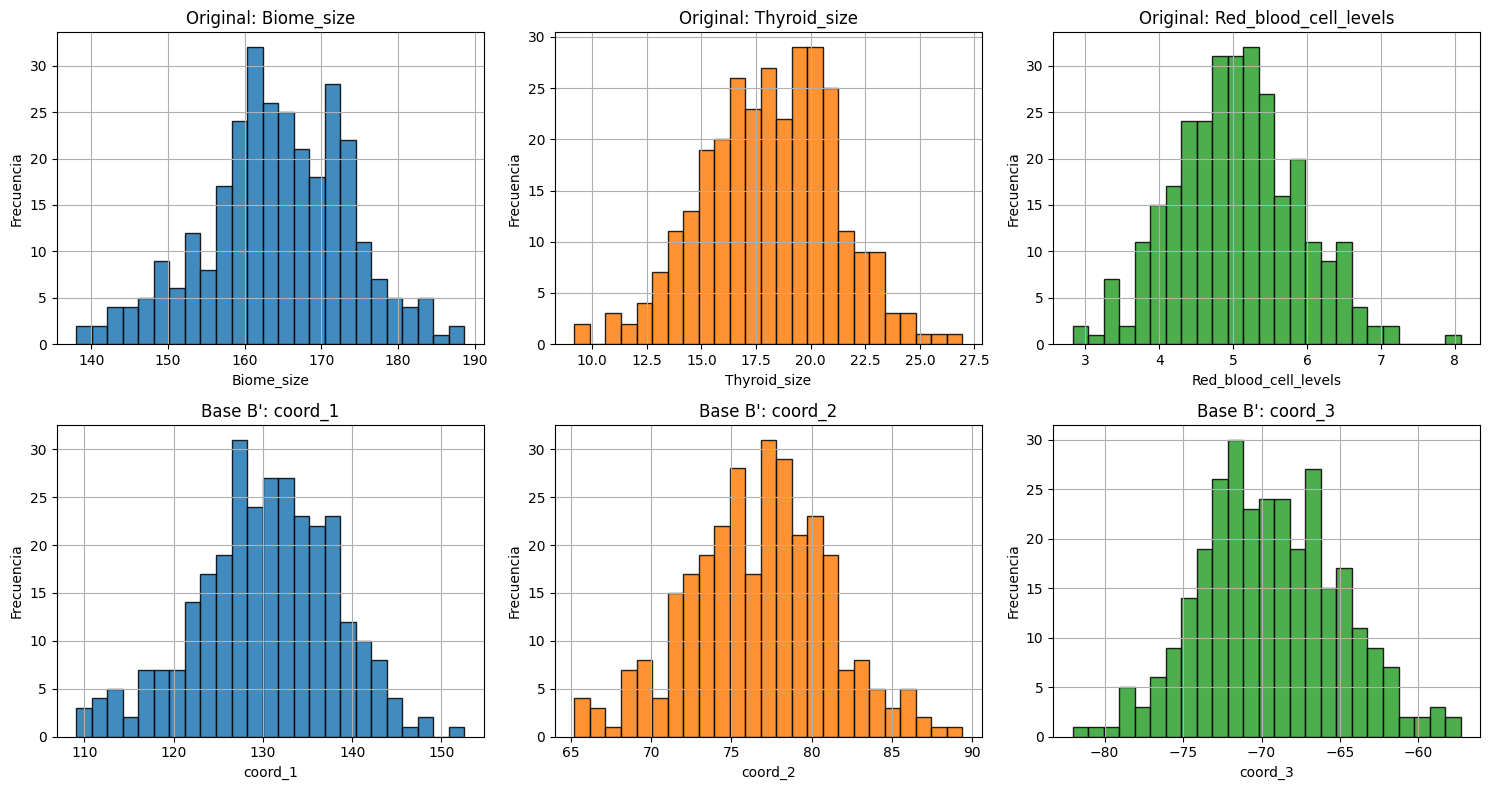

In [6]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))

vars_orig = ["Biome_size", "Thyroid_size", "Red_blood_cell_levels"]
vars_nuevas = ["coord_1", "coord_2", "coord_3"]
colores = ["#1f77b4", "#ff7f0e", "#2ca02c"]

for i, (col, c) in enumerate(zip(vars_orig, colores)):
    axes[0, i].hist(df[col], bins=25, color=c, edgecolor="black", alpha=0.85)
    axes[0, i].set_title(f"Original: {col}")
    axes[0, i].set_xlabel(col)
    axes[0, i].set_ylabel("Frecuencia")

for i, (col, c) in enumerate(zip(vars_nuevas, colores)):
    axes[1, i].hist(df_Bp[col], bins=25, color=c, edgecolor="black", alpha=0.85)
    axes[1, i].set_title(f"Base B': {col}")
    axes[1, i].set_xlabel(col)
    axes[1, i].set_ylabel("Frecuencia")

plt.tight_layout()
plt.savefig("histogramas_comparativos.png", dpi=120)
plt.show()


## 6. Visualización 3D de los datos en la nueva base

Ahora vamos a representar los datos en un gráfico 3D usando los tres nuevos ejes de la base $B'$. Sobre el mismo gráfico dibujaremos además los vectores de la base $B'$ como flechas que parten del origen, para tener una referencia visual de cómo están orientados los nuevos ejes respecto al sistema original.


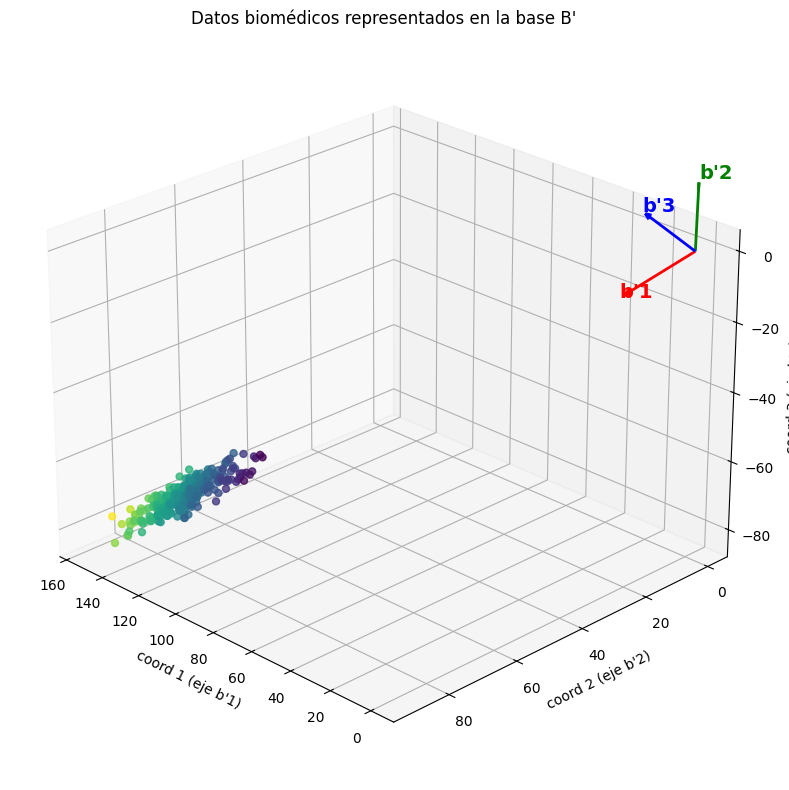

In [7]:
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection="3d")

ax.scatter(df_Bp["coord_1"], df_Bp["coord_2"], df_Bp["coord_3"],
           c=df_Bp["coord_1"], cmap="viridis", s=25, alpha=0.8)

origen = np.zeros(3)
colores_ejes = ["red", "green", "blue"]
etiquetas = ["b'1", "b'2", "b'3"]
escala = 3 * np.sqrt(np.max(var_nueva))

for i in range(3):
    v = Bp[:, i] * escala
    ax.quiver(0, 0, 0, v[0], v[1], v[2],
              color=colores_ejes[i], arrow_length_ratio=0.1, linewidth=2)
    ax.text(v[0]*1.05, v[1]*1.05, v[2]*1.05, etiquetas[i],
            color=colores_ejes[i], fontsize=14, fontweight="bold")

ax.set_xlabel("coord 1 (eje b'1)")
ax.set_ylabel("coord 2 (eje b'2)")
ax.set_zlabel("coord 3 (eje b'3)")
ax.set_title("Datos biomédicos representados en la base B'")
ax.view_init(elev=25, azim=135)
plt.tight_layout()
plt.savefig("datos_3d_base_Bp.png", dpi=120)
plt.show()


## 7. Visualización adicional: datos en la base original

Para poder comparar, también visualizamos los mismos datos usando los ejes originales (Biome_size, Thyroid_size, Red_blood_cell_levels). Esto nos permite apreciar la diferencia de orientación entre las dos bases.


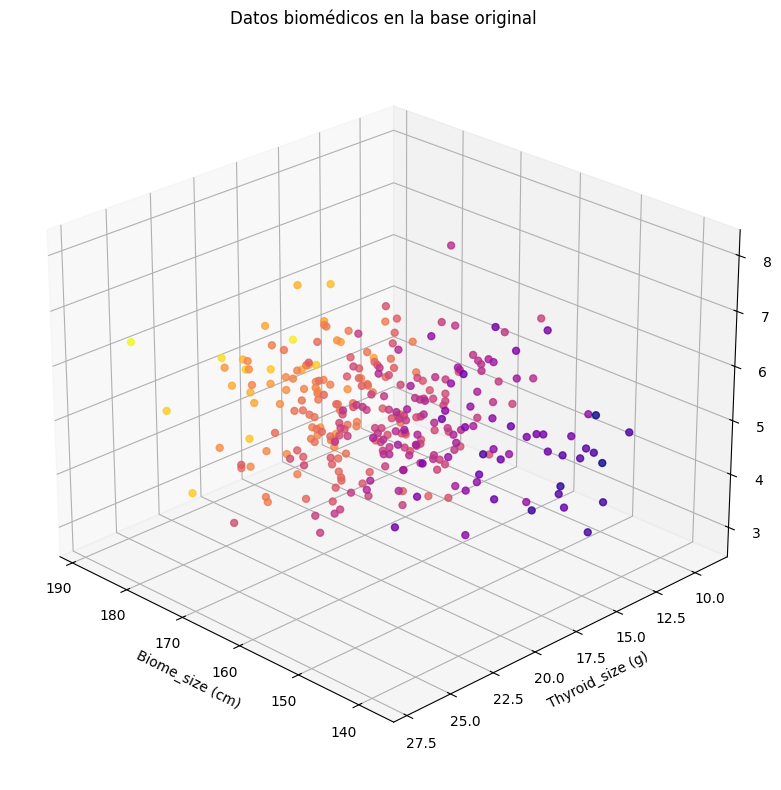

In [8]:
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection="3d")

ax.scatter(df["Biome_size"], df["Thyroid_size"], df["Red_blood_cell_levels"],
           c=df["Biome_size"], cmap="plasma", s=25, alpha=0.8)

ax.set_xlabel("Biome_size (cm)")
ax.set_ylabel("Thyroid_size (g)")
ax.set_zlabel("Red_blood_cell_levels (M/µL)")
ax.set_title("Datos biomédicos en la base original")
ax.view_init(elev=25, azim=135)
plt.tight_layout()
plt.savefig("datos_3d_base_original.png", dpi=120)
plt.show()


## 8. Respuesta a la pregunta clave

**¿Esta nueva base parece separar mejor la información? ¿Se observa algún efecto similar de reducción de varianza en alguna de las nuevas coordenadas como en el caso anterior?**

A partir de los resultados obtenidos podemos concluir:

- La base $B'$ está formada por tres vectores aproximadamente ortonormales (normas $\approx 1$ y productos internos $\approx 0$), por lo que se trata esencialmente de una **rotación** del sistema de coordenadas original.
- Como toda rotación, la **varianza total se conserva**: la suma de las varianzas en la base original coincide con la suma de las varianzas en la base $B'$. Lo que cambia es cómo se reparte esa varianza entre las nuevas coordenadas.
- Una rotación arbitraria **no garantiza** que una coordenada concentre casi toda la varianza (eso es justamente lo que hace el PCA al elegir los ejes de máxima varianza). Por eso, en general la base $B'$ **no separa mejor** la información que la base original ni produce el mismo efecto de reducción de varianza que se observó en el caso anterior.
- Sin embargo, al cambiar de base las coordenadas dejan de estar correlacionadas, lo cual puede ser útil como paso previo para análisis posteriores (por ejemplo, compresión, regresión o clasificación).
